In [9]:
KAGGLE=False

In [4]:
if KAGGLE:
    !pip install scikit-learn==1.6.1
    !pip install xgboost==3.0.1
    !pip install imbalanced-learn-0.13.0
    
    import kagglehub
    path = kagglehub.dataset_download("sgpjesus/bank-account-fraud-dataset-neurips-2022")
else: 
    from pathlib import Path

In [3]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay

from imblearn.under_sampling import NearMiss
from imblearn.over_sampling import SMOTENC

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('

In [7]:
if KAGGLE:
    df = pd.read_csv('/kaggle/input/bank-account-fraud-dataset-neurips-2022/Base.csv')
else:
    PROJECT_ROOT = Path.cwd().parent
    df = pd.read_csv(PROJECT_ROOT / "data" / "Bank Account Fraud Dataset" / "account_fraud.csv")
    
df = df.drop('device_fraud_count', axis=1)

X = df.drop('fraud_bool', axis=1)
y = df['fraud_bool']

In [5]:
transformers=[('ohe', OneHotEncoder(drop=None, sparse_output=False), ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os'])]

ct = ColumnTransformer(
    transformers,
    remainder='passthrough'
)

nm = NearMiss(sampling_strategy=0.1, n_jobs=-1)

# Correct division into training and test samples and preprocessing
X_tr, X_tt, y_tr, y_tt = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
X_tr = pd.DataFrame(ct.fit_transform(X_tr),columns = ct.get_feature_names_out())
X_tt = pd.DataFrame(ct.fit_transform(X_tt),columns = ct.get_feature_names_out())
X_tr, y_tr = nm.fit_resample(X_tr, y_tr)

# Using NearMiss on the all data and devision
X_nm = pd.DataFrame(ct.fit_transform(X),columns = ct.get_feature_names_out())
X_nm, y_nm = nm.fit_resample(X_nm, y)
X_tr_nm, X_tt_nm, y_tr_nm, y_tt_nm = train_test_split(X_nm, y_nm, test_size=0.25, random_state=42, stratify=y_nm)

In [6]:
feat = [X_tr.columns.get_loc(str(feature)) for feature in X_tr.columns if X_tr[feature].nunique() >= 2 and X_tr[feature].nunique() < 10]
smote = SMOTENC(categorical_features=feat, sampling_strategy='minority', random_state=42)

X_tr, y_tr = smote.fit_resample(X_tr, y_tr)


feat_nm = [X_tr_nm.columns.get_loc(str(feature)) for feature in X_tr_nm.columns if X_tr_nm[feature].nunique() >= 2 and X_tr_nm[feature].nunique() < 10]
smote_nm = SMOTENC(categorical_features=feat, sampling_strategy='minority', random_state=42)

X_tr_nm, y_tr_nm = smote_nm.fit_resample(X_tr_nm, y_tr_nm)

In [7]:
# Correct devided
xgb_co = XGBClassifier(subsample=0.6, n_estimators=100, min_child_weight=2, max_depth=10, learning_rate=0.15, colsample_bytree=0.8)

# With NearMiss on the all data
xgb_nm = XGBClassifier(subsample=0.6, n_estimators=100, min_child_weight=2, max_depth=10, learning_rate=0.15, colsample_bytree=0.8)

xgb_co.fit(X_tr, y_tr)
xgb_nm.fit(X_tr_nm, y_tr_nm)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


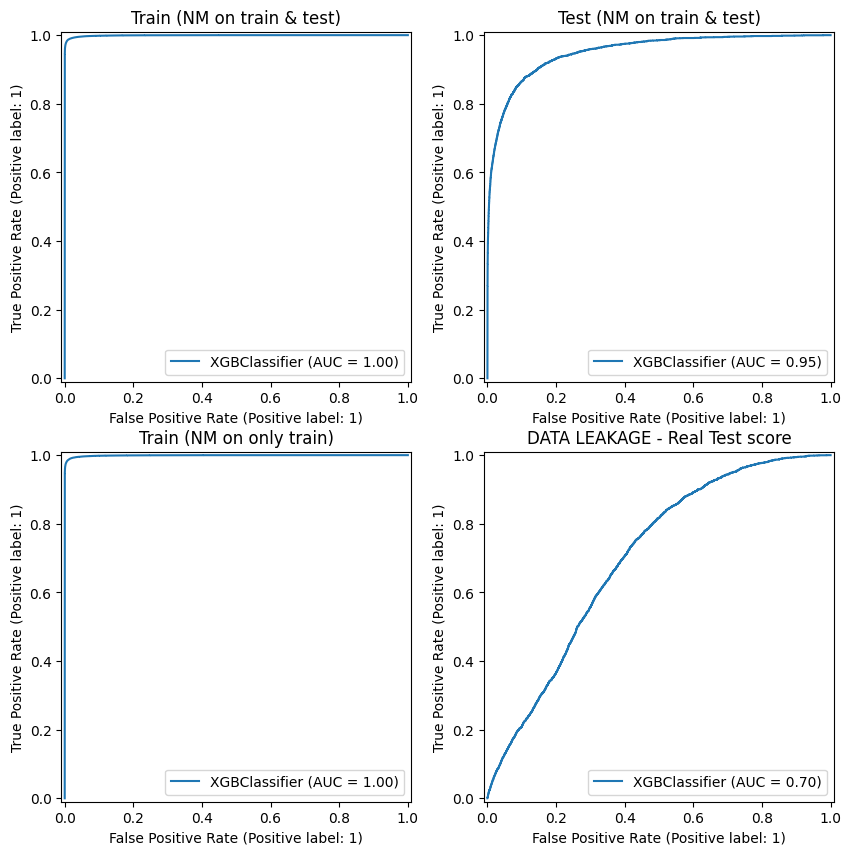

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

RocCurveDisplay.from_estimator(xgb_nm, X_tr_nm, y_tr_nm, ax=axes[0][0])
RocCurveDisplay.from_estimator(xgb_nm, X_tt_nm, y_tt_nm, ax=axes[0][1])

axes[0][0].set_title('Train (NM on train & test)')
axes[0][1].set_title('Test (NM on train & test)')



RocCurveDisplay.from_estimator(xgb_co, X_tr, y_tr, ax=axes[1][0])
RocCurveDisplay.from_estimator(xgb_co, X_tt, y_tt, ax=axes[1][1])
axes[1][0].set_title('Train (NM on only train)')
axes[1][1].set_title('DATA LEAKAGE - Real Test score')



plt.show()